# 프로젝트: mini BERT 만들기 (1M Parameters)

## 프로젝트 개요
- **목표**: vocab_size 8000, 전체 파라미터 ~1M의 작은 mini BERT 모델을 만들어 10 Epoch까지 학습
- **데이터**: 한글 나무위키 코퍼스 (kowiki.txt)
- **Task**: MLM (Masked Language Model) + NSP (Next Sentence Prediction)
- **핵심 평가 기준**:
  1. 1M짜리 mini BERT 모델의 제작과 학습이 정상적으로 진행
  2. MLM, NSP loss의 안정적인 감소 확인
  3. 한글 코퍼스를 가공하여 BERT pretrain용 데이터셋을 체계적으로 생성

## 1. 환경 설정 및 데이터 다운로드

작업 디렉토리를 생성하고, 필요한 라이브러리를 설치합니다.  
학습에 사용할 한글 나무위키 코퍼스 데이터를 다운로드합니다.

In [38]:
# Cell Number 1
import os

# 작업 디렉토리 생성
os.makedirs('data', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('work', exist_ok=True)

In [39]:
# Cell Number 2
# 필요한 라이브러리 설치
!pip install sentencepiece tqdm torchinfo korpora


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


In [40]:
# Cell Number 3
# 데이터 준비 — 다운로드된 파일을 직접 읽어 kowiki.txt 생성
# Korpora.load()는 대용량 파일에서 대화형 입력을 요구하므로 원본 파일 직접 사용

import re

train_file = 'data/korpora/kowikitext/kowikitext_20200920.train'
output_path = 'data/kowiki.txt'

# kowikitext 포맷:
#   " = 제목 = "       → 문서/섹션 구분자 (빈 줄로 변환)
#   일반 텍스트 줄      → 그대로 사용
#   빈 줄               → 그대로 유지

print("kowiki.txt 변환 중... (1~2분 소요)")

header_pattern = re.compile(r'^\s*=+\s*.+\s*=+\s*$')  # = 제목 = 패턴

with open(train_file, 'r', encoding='utf-8') as in_f, \
     open(output_path, 'w', encoding='utf-8') as out_f:

    prev_blank = False
    for line in in_f:
        line = line.strip()

        if header_pattern.match(line):
            # 섹션 헤더 → 문서 경계 빈 줄로 변환
            if not prev_blank:
                out_f.write('\n')
                prev_blank = True
        elif line == '':
            # 빈 줄 유지 (단, 연속 빈 줄은 하나로)
            if not prev_blank:
                out_f.write('\n')
                prev_blank = True
        else:
            # 일반 텍스트
            out_f.write(line + '\n')
            prev_blank = False

print("데이터 준비 완료!")
print(f"파일 크기: {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")

kowiki.txt 변환 중... (1~2분 소요)
데이터 준비 완료!
파일 크기: 1525.2 MB


In [41]:
# Cell Number 3-1 : kowiki.txt 데이터 구조 확인

# 1. 파일 크기
print(f"[파일 크기] {os.path.getsize(output_path) / 1024 / 1024:.1f} MB")

# 2. 전체 라인 수 & 빈 줄(문서 경계) 수
total_lines = 0
blank_lines = 0
with open(output_path, 'r', encoding='utf-8') as f:
    for line in f:
        total_lines += 1
        if line.strip() == '':
            blank_lines += 1

print(f"[전체 라인 수] {total_lines:,}")
print(f"[빈 줄 수 = 문서 경계] {blank_lines:,}")
print(f"[텍스트 라인 수] {total_lines - blank_lines:,}")

# 3. 앞부분 30줄 출력 (구조 확인)
print("\n[앞부분 30줄 미리보기]")
print("-" * 60)
with open(output_path, 'r', encoding='utf-8') as f:
    for i, line in enumerate(f):
        if i >= 30:
            break
        # 빈 줄은 <BLANK> 로 표시해서 구분 쉽게
        display = line.rstrip() if line.strip() else "<BLANK LINE — 문서 경계>"
        print(f"{i+1:3d} | {display}")

[파일 크기] 1525.2 MB
[전체 라인 수] 19,751,507
[빈 줄 수 = 문서 경계] 5,621,969
[텍스트 라인 수] 14,129,538

[앞부분 30줄 미리보기]
------------------------------------------------------------
  1 | <BLANK LINE — 문서 경계>
  2 | 외교부장
  3 | 외교부장
  4 | <BLANK LINE — 문서 경계>
  5 | 공원
  6 | 공원
  7 | <BLANK LINE — 문서 경계>
  8 | 김세권(1931년 ~ ,金世權) 은 제16대 서울고등검찰청 검사장을 역임한 법조인이다.
  9 | <BLANK LINE — 문서 경계>
 10 | 1931년 서울시에서 태어나 경기중학교,1982년 4월 12일자 매일경제 서울고등학교,1981년 4월 25일자 동아일보 1956년 서울대학교 법학과를 나온 후 1956년 제8회 고등고시 사법과에서 합격하였다. 1958년 서울지방검찰청 검사에 임용되었다.
 11 | <BLANK LINE — 문서 경계>
 12 | 김세권은 두산그룹 창업주인 박두병 딸인 박용언과 결혼했다.  김세권과 박용언은 아들은 1970년대 봉제업으로 성장한 태흥의 창업주 권태흥의 딸 권혜경과 결혼한 김형일 일경산업개발 부회장으로 1990년대 초반 대한민국에 게스·폴로 등을 수입해 유명세를 탔던 기업가다. 딸 김희정의 남편은 최원현 케이씨엘 대표변호사다.박승직 박두병 박용곤 박정원 재벌가 4대 33명 결혼 스토리
 13 | <BLANK LINE — 문서 경계>
 14 | 대검찰청 차장으로 재직하던 1986년 2월 전국 검사장 회의를 주재하면서 "국법질서 확립을 위한 검찰의 과제"라는 주제로 토의를 하여 국법질서와 사회기강 확립, 경제도약의 전기가 될 수 있는 현재의 국내외 경제여건을 최대한 유지, 활용할 수 있도록 경제질서교란사범 엄단, 민생을 불안하게 하는 반윤리적인 강력사범에 대한 단호한 응징, 사회적 신분과 지위의 고하를 가리지 않는

In [42]:
# Cell Number 4
# imports
from __future__ import absolute_import, division, print_function, unicode_literals

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optimd
from torch.utils.data import DataLoader, TensorDataset
from torchinfo import summary

import os
import re
import math
import numpy as np
import pandas as pd
import random
import collections
import json
import shutil
import zipfile
import copy
from datetime import datetime

import matplotlib.pyplot as plt
import sentencepiece as spm
from tqdm.notebook import tqdm

# 재현성을 위한 시드 설정
random_seed = 1234
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)

# 디바이스 설정 (CUDA → MPS → CPU 순으로 자동 선택)
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")   # Apple Silicon GPU
else:
    device = torch.device("cpu")

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif device.type == "mps":
    print("Apple Silicon GPU (MPS) 사용 중 — CPU보다 훨씬 빠릅니다!")

PyTorch version: 2.10.0
Device: mps
Apple Silicon GPU (MPS) 사용 중 — CPU보다 훨씬 빠릅니다!


## 2. Tokenizer 준비

SentencePiece 기반의 BPE 토크나이저를 학습합니다.  
프로젝트 요구사항에 따라 **vocab_size = 8000**으로 설정합니다.  
BERT에서 사용하는 `[MASK]`, `[SEP]`, `[CLS]` 등의 특수문자가 vocab에 포함되어야 합니다.

In [43]:
# Cell Number 5
# SentencePiece 토크나이저 학습
corpus_file = 'data/kowiki.txt'
prefix = 'models/ko_8000'
vocab_size = 8000

# SentencePiece 학습 (약 10~20분 소요될 수 있습니다)
spm.SentencePieceTrainer.train(
    f"--input={corpus_file} "
    f"--model_prefix={prefix} "
    f"--vocab_size={vocab_size + 7} "
    f"--model_type=bpe "
    f"--max_sentence_length=999999 "
    f"--pad_id=0 --pad_piece=[PAD] "
    f"--unk_id=1 --unk_piece=[UNK] "
    f"--bos_id=2 --bos_piece=[BOS] "
    f"--eos_id=3 --eos_piece=[EOS] "
    f"--user_defined_symbols=[SEP],[CLS],[MASK]"
)

print(f"토크나이저 학습 완료!")
print(f"모델 파일: {prefix}.model")
print(f"Vocab 파일: {prefix}.vocab")

토크나이저 학습 완료!
모델 파일: models/ko_8000.model
Vocab 파일: models/ko_8000.vocab


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=data/kowiki.txt --model_prefix=models/ko_8000 --vocab_size=8007 --model_type=bpe --max_sentence_length=999999 --pad_id=0 --pad_piece=[PAD] --unk_id=1 --unk_piece=[UNK] --bos_id=2 --bos_piece=[BOS] --eos_id=3 --eos_piece=[EOS] --user_defined_symbols=[SEP],[CLS],[MASK]
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: data/kowiki.txt
  input_format: 
  model_prefix: models/ko_8000
  model_type: BPE
  vocab_size: 8007
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 999999
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  user_defined_sym

In [44]:
# Cell Number 6
# vocab 로딩 및 확인
vocab = spm.SentencePieceProcessor()
vocab.load(f"{prefix}.model")

print(f"Vocab size: {len(vocab)}")
print(f"[PAD] id: {vocab.piece_to_id('[PAD]')}")
print(f"[UNK] id: {vocab.piece_to_id('[UNK]')}")
print(f"[BOS] id: {vocab.piece_to_id('[BOS]')}")
print(f"[EOS] id: {vocab.piece_to_id('[EOS]')}")
print(f"[SEP] id: {vocab.piece_to_id('[SEP]')}")
print(f"[CLS] id: {vocab.piece_to_id('[CLS]')}")
print(f"[MASK] id: {vocab.piece_to_id('[MASK]')}")

Vocab size: 8007
[PAD] id: 0
[UNK] id: 1
[BOS] id: 2
[EOS] id: 3
[SEP] id: 4
[CLS] id: 5
[MASK] id: 6


In [45]:
# Cell Number 7
# 특수 token 7개를 제외한 나머지 vocab_list 생성 (random masking 용)
vocab_list = []
for id in range(7, len(vocab)):
    if not vocab.is_unknown(id):
        vocab_list.append(vocab.id_to_piece(id))

print(f"vocab_list 크기 (특수문자 제외): {len(vocab_list)}")
print(f"샘플: {vocab_list[:10]}")

vocab_list 크기 (특수문자 제외): 8000
샘플: ['▁1', '▁2', '▁이', '▁(', '▁20', '으로', '에서', '▁있', '▁!', '▁사']


In [46]:
# Cell Number 8
# 토크나이저 테스트
string_a = "추적추적 비가 내리는 날이었어 그날은 왠지 손님이 많아"
string_b = "손바닥 위엔 기쁨의 눈물이 흘러 컬컬한 목에 모주 한잔을 적셔"

tokens_org = ["[CLS]"] + vocab.encode_as_pieces(string_a) + ["[SEP]"] + \
             vocab.encode_as_pieces(string_b) + ["[SEP]"]
print("토크나이징 결과:")
print(tokens_org)
print(f"토큰 수: {len(tokens_org)}")

토크나이징 결과:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물', '이', '▁', '흘', '러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']
토큰 수: 51


## 3. 데이터 전처리

### 3.1 MASK 생성 (Masked Language Model)

BERT의 MLM은 학습 데이터 전체에서 **15%를 마스킹** 합니다:
- 80%: `[MASK]` 토큰으로 교체
- 10%: 랜덤한 토큰으로 교체  
- 10%: 원래 토큰 그대로 유지

단어 단위(띄어쓰기 기준)로 마스킹하여 subword가 함께 마스킹되도록 합니다.

In [47]:
# Cell Number 9
def create_pretrain_mask(tokens, mask_cnt, vocab_list):
    """
    마스크 생성
    :param tokens: tokens
    :param mask_cnt: mask 개수 (전체 tokens의 15%)
    :param vocab_list: vocab list (random token 용)
    :return tokens: mask된 tokens
    :return mask_idx: mask된 token의 index
    :return mask_label: mask된 token의 원래 값
    """
    # 단어 단위로 mask하기 위해서 index 분할 (띄어쓰기)
    cand_idx = []
    for (i, token) in enumerate(tokens):
        if token == "[CLS]" or token == "[SEP]":
            continue
        if 0 < len(cand_idx) and not token.startswith(u"\u2581"): #cand_idx : Candidate Indices 의 줄임말입니다. "마스킹 후보 인덱스들"
            cand_idx[-1].append(i)
        else:
            cand_idx.append([i])
    
    # random mask를 위해서 순서를 섞음
    random.shuffle(cand_idx)
    
    mask_lms = []
    for index_set in cand_idx:
        if len(mask_lms) >= mask_cnt:
            break
        if len(mask_lms) + len(index_set) > mask_cnt:
            continue
        dice = random.random()
        for index in index_set:
            masked_token = None
            if dice < 0.8:        # 80% -> [MASK]
                masked_token = "[MASK]"
            elif dice < 0.9:      # 10% -> 원래 토큰 유지
                masked_token = tokens[index]
            else:                 # 10% -> 랜덤 토큰
                masked_token = random.choice(vocab_list)
            mask_lms.append({"index": index, "label": tokens[index]})
            tokens[index] = masked_token
    
    # 정렬 후 mask_idx, mask_label 추출
    mask_lms = sorted(mask_lms, key=lambda x: x["index"])
    mask_idx = [p["index"] for p in mask_lms]
    mask_label = [p["label"] for p in mask_lms]
    
    return tokens, mask_idx, mask_label

# 마스킹 테스트
tokens_test = copy.deepcopy(tokens_org)
mask_cnt = int((len(tokens_test) - 3) * 0.15)
tokens_masked, mask_idx, mask_label = create_pretrain_mask(tokens_test, mask_cnt, vocab_list)

print("원본 tokens:")
print(tokens_org)
print(f"\n마스킹된 tokens:")
print(tokens_masked)
print(f"\nmask_idx: {mask_idx}")
print(f"mask_label: {mask_label}")

원본 tokens:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '▁내', '리는', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '▁손', '님이', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물', '이', '▁', '흘', '러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '▁한', '잔', '을', '▁적', '셔', '[SEP]']

마스킹된 tokens:
['[CLS]', '▁추', '적', '추', '적', '▁비', '가', '[MASK]', '[MASK]', '▁날', '이었', '어', '▁그', '날', '은', '▁', '왠', '지', '[MASK]', '[MASK]', '▁많', '아', '[SEP]', '▁손', '바', '닥', '▁위', '엔', '▁기', '쁨', '의', '▁눈', '물', '이', '▁', '흘', '러', '▁', '컬', '컬', '한', '▁목', '에', '▁모', '주', '[MASK]', '[MASK]', '[MASK]', '▁적', '셔', '[SEP]']

mask_idx: [7, 8, 18, 19, 45, 46, 47]
mask_label: ['▁내', '리는', '▁손', '님이', '▁한', '잔', '을']


### 3.2 NSP pair 생성 (Next Sentence Prediction)

BERT의 NSP task는 두 문장이 연속하는지를 판단합니다:
- 50% 확률로 실제 연속 문장 → `is_next = 1` (True)
- 50% 확률로 swap → `is_next = 0` (False)

In [48]:
# Cell Number 10
def trim_tokens(tokens_a, tokens_b, max_seq):
    """
    tokens_a, tokens_b의 길이를 줄임. 최대 길이: max_seq
    """
    while True:
        total_length = len(tokens_a) + len(tokens_b)
        if total_length <= max_seq:
            break
        if len(tokens_a) > len(tokens_b):
            del tokens_a[0]
        else:
            tokens_b.pop()

### 3.3 데이터셋 완성

위의 MLM과 NSP를 결합하여 최종 pretrain 데이터셋을 생성합니다.  
각 instance는 다음을 포함합니다:
- `tokens`: [CLS] + tokens_a + [SEP] + tokens_b + [SEP] (마스킹 적용)
- `segment`: 문장 A는 0, 문장 B는 1
- `is_next`: NSP 레이블
- `mask_idx`: 마스킹된 위치
- `mask_label`: 마스킹된 원래 토큰

In [49]:
# Cell Number 11
def create_pretrain_instances(vocab, doc, n_seq, mask_prob, vocab_list):
    """
    doc별 pretrain 데이터 생성
    :param vocab: SentencePiece vocab
    :param doc: 문서 (줄 단위 토큰 리스트)
    :param n_seq: 시퀀스 길이
    :param mask_prob: 마스킹 비율 (0.15)
    :param vocab_list: vocab list (random token 용)
    :return instances: pretrain instance 리스트
    """
    # [CLS], [SEP], [SEP] 3개 제외
    max_seq = n_seq - 3
    
    instances = []
    current_chunk = []
    current_length = 0
    
    for i in range(len(doc)):
        current_chunk.append(doc[i])
        current_length += len(doc[i])
        
        if 1 < len(current_chunk) and (i == len(doc) - 1 or current_length >= max_seq):
            # token a 생성
            a_end = 1
            if 1 < len(current_chunk):
                a_end = random.randrange(1, len(current_chunk))
            tokens_a = []
            for j in range(a_end):
                tokens_a.extend(current_chunk[j])
            
            # token b 생성
            tokens_b = []
            for j in range(a_end, len(current_chunk)):
                tokens_b.extend(current_chunk[j])
            
            # NSP: 50% 확률로 swap
            if random.random() < 0.5:
                is_next = 0  # False (swap됨)
                tokens_t = tokens_a
                tokens_a = tokens_b
                tokens_b = tokens_t
            else:
                is_next = 1  # True (원래 순서)
            
            # max_seq 보다 큰 경우 길이 조절
            trim_tokens(tokens_a, tokens_b, max_seq)
            assert 0 < len(tokens_a)
            assert 0 < len(tokens_b)
            
            # tokens & segment 생성
            tokens = ["[CLS]"] + tokens_a + ["[SEP]"] + tokens_b + ["[SEP]"]
            segment = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)
            
            # mask 적용
            tokens, mask_idx, mask_label = create_pretrain_mask(
                tokens, int((len(tokens) - 3) * mask_prob), vocab_list
            )
            
            instance = {
                "tokens": tokens,
                "segment": segment,
                "is_next": is_next,
                "mask_idx": mask_idx,
                "mask_label": mask_label
            }
            instances.append(instance)
            
            current_chunk = []
            current_length = 0
    
    return instances

print("create_pretrain_instances 함수 정의 완료!")

create_pretrain_instances 함수 정의 완료!


In [50]:
# Cell Number 12
def make_pretrain_data(vocab, in_file, out_file, n_seq, mask_prob=0.15):
    """
    전체 코퍼스를 읽어 pretrain 데이터를 json으로 저장
    """
    # 특수문자 7개를 제외한 vocab_list 생성
    vocab_list = []
    for id in range(7, len(vocab)):
        if not vocab.is_unknown(id):
            vocab_list.append(vocab.id_to_piece(id))
    
    # line count 확인
    line_cnt = 0
    with open(in_file, "r") as in_f:
        for line in in_f:
            line_cnt += 1
    print(f"전체 라인 수: {line_cnt:,}")
    
    with open(in_file, "r") as in_f:
        with open(out_file, "w") as out_f:
            doc = []
            for line in tqdm(in_f, total=line_cnt, desc="데이터 생성"):
                line = line.strip()
                if line == "":  # 빈줄 = 새로운 단락
                    if 0 < len(doc):
                        instances = create_pretrain_instances(
                            vocab, doc, n_seq, mask_prob, vocab_list
                        )
                        for instance in instances:
                            out_f.write(json.dumps(instance, ensure_ascii=False))
                            out_f.write("\n")
                        doc = []
                else:
                    pieces = vocab.encode_as_pieces(line)
                    if 0 < len(pieces):
                        doc.append(pieces)
            
            # 마지막에 처리되지 않은 doc
            if 0 < len(doc):
                instances = create_pretrain_instances(
                    vocab, doc, n_seq, mask_prob, vocab_list
                )
                for instance in instances:
                    out_f.write(json.dumps(instance, ensure_ascii=False))
                    out_f.write("\n")
                doc = []
    
    print("pretrain 데이터 생성 완료!")

# pretrain 데이터 생성 (약 30~60분 소요)
pretrain_json_path = 'work/bert_pre_train.json'
make_pretrain_data(vocab, corpus_file, pretrain_json_path, n_seq=128)

전체 라인 수: 19,751,507


데이터 생성:   0%|          | 0/19751507 [00:00<?, ?it/s]

pretrain 데이터 생성 완료!


In [51]:
# Cell Number 13
# 생성된 데이터 확인
total = 0
with open(pretrain_json_path, "r") as f:
    for line in f:
        total += 1

print(f"전체 pretrain 데이터 수: {total:,}")

# 샘플 확인
with open(pretrain_json_path, "r") as f:
    sample = json.loads(f.readline())
    print(f"\n샘플 데이터:")
    print(f"  tokens 길이: {len(sample['tokens'])}")
    print(f"  segment 길이: {len(sample['segment'])}")
    print(f"  is_next: {sample['is_next']}")
    print(f"  mask_idx 수: {len(sample['mask_idx'])}")
    print(f"  tokens 앞부분: {sample['tokens'][:20]}")

전체 pretrain 데이터 수: 2,135,681

샘플 데이터:
  tokens 길이: 7
  segment 길이: 7
  is_next: 1
  mask_idx 수: 0
  tokens 앞부분: ['[CLS]', '▁외교', '부장', '[SEP]', '▁외교', '부장', '[SEP]']


### 3.4 데이터 로딩

생성된 JSON 데이터를 numpy memmap으로 변환하여 메모리 효율적으로 로딩합니다.  
전체 데이터 중 **128,000건**만 사용합니다.

In [52]:
# Cell Number 14
def load_pre_train_data(vocab, filename, n_seq, count=None):
    """
    학습에 필요한 데이터를 로드
    :param vocab: vocab
    :param filename: 전처리된 json 파일
    :param n_seq: 시퀀스 길이
    :param count: 데이터 수 제한 (None이면 전체)
    :return enc_tokens, segments: encoder inputs
    :return labels_nsp, labels_mlm: labels
    """
    total = 0
    with open(filename, "r") as f:
        for line in f:
            total += 1
            if count is not None and count <= total:
                break
    
    print(f"로딩할 데이터 수: {total:,}")
    
    # np.memmap으로 메모리 효율적 처리
    enc_tokens = np.memmap(filename='work/enc_tokens.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    segments = np.memmap(filename='work/segments.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    labels_nsp = np.memmap(filename='work/labels_nsp.memmap', mode='w+', dtype=np.int32, shape=(total,))
    labels_mlm = np.memmap(filename='work/labels_mlm.memmap', mode='w+', dtype=np.int32, shape=(total, n_seq))
    
    with open(filename, "r") as f:
        for i, line in enumerate(tqdm(f, total=total, desc="데이터 로딩")):
            if total <= i:
                break
            data = json.loads(line)
            
            # encoder token
            enc_token = [vocab.piece_to_id(p) for p in data["tokens"]]
            enc_token += [0] * (n_seq - len(enc_token))
            
            # segment
            segment = data["segment"]
            segment += [0] * (n_seq - len(segment))
            
            # nsp label
            label_nsp = data["is_next"]
            
            # mlm label
            mask_idx = np.array(data["mask_idx"], dtype=np.int32)
            mask_label = np.array([vocab.piece_to_id(p) for p in data["mask_label"]], dtype=np.int32)
            label_mlm = np.full(n_seq, dtype=np.int32, fill_value=0)
            label_mlm[mask_idx] = mask_label
            
            assert len(enc_token) == len(segment) == len(label_mlm) == n_seq
            
            enc_tokens[i] = enc_token
            segments[i] = segment
            labels_nsp[i] = label_nsp
            labels_mlm[i] = label_mlm
    
    return (enc_tokens, segments), (labels_nsp, labels_mlm)

# 128,000건만 로딩
n_seq = 128
pre_train_inputs, pre_train_labels = load_pre_train_data(
    vocab, pretrain_json_path, n_seq, count=128000
)

print(f"\nenc_tokens shape: {pre_train_inputs[0].shape}")
print(f"segments shape: {pre_train_inputs[1].shape}")
print(f"labels_nsp shape: {pre_train_labels[0].shape}")
print(f"labels_mlm shape: {pre_train_labels[1].shape}")

로딩할 데이터 수: 128,000


데이터 로딩:   0%|          | 0/128000 [00:00<?, ?it/s]


enc_tokens shape: (128000, 128)
segments shape: (128000, 128)
labels_nsp shape: (128000,)
labels_mlm shape: (128000, 128)


## 4. BERT 모델 구현

### 모델 설계 (1M 파라미터)

| 항목 | 값 | 설명 |
|------|------|------|
| vocab_size | 8,000 | 프로젝트 요구사항 |
| d_model | 64 | 임베딩 차원 |
| n_head | 4 | 어텐션 헤드 수 |
| d_head | 16 | 헤드별 차원 (d_model / n_head) |
| d_ff | 256 | FFN 히든 차원 |
| n_layer | 4 | 인코더 레이어 수 |
| n_seq | 128 | 시퀀스 길이 |

BERT의 3가지 임베딩:
- **Token Embedding**: 토큰 자체의 임베딩
- **Segment Embedding**: 문장 A/B 구분
- **Position Embedding**: 위치 정보 (학습 가능)

In [53]:
# Cell Number 15
# =====================================
# 유틸리티 함수
# =====================================

def get_pad_mask(tokens, i_pad=0):
    """pad mask 생성 (pad: 1, other: 0)"""
    mask = (tokens == i_pad).float()
    mask = mask.unsqueeze(1)
    return mask

def get_ahead_mask(tokens, i_pad=0):
    """ahead mask 계산 (causal + pad mask)"""
    n_seq = tokens.size(1)
    ahead_mask = 1 - torch.tril(torch.ones((n_seq, n_seq)))
    ahead_mask = ahead_mask.unsqueeze(0)
    pad_mask = get_pad_mask(tokens, i_pad)
    mask = torch.maximum(ahead_mask, pad_mask)
    return mask

def gelu(x):
    """GELU activation 함수"""
    return 0.5 * x * (1 + torch.tanh(math.sqrt(2 / math.pi) * (x + 0.044715 * torch.pow(x, 3))))

def kernel_initializer(stddev=0.02):
    """parameter initializer 생성"""
    return torch.nn.init.trunc_normal_

def bias_initializer():
    """bias initializer 생성"""
    return torch.zeros_

print("유틸리티 함수 정의 완료!")

유틸리티 함수 정의 완료!


In [54]:
# Cell Number 16
# =====================================
# Config 클래스
# =====================================

class Config(dict):
    """json을 config 형태로 사용하기 위한 Class"""
    __getattr__ = dict.__getitem__
    __setattr__ = dict.__setitem__
    
    @classmethod
    def load(cls, file):
        with open(file, 'r') as f:
            config = json.loads(f.read())
            return Config(config)

# 1M 파라미터 mini BERT config
config = Config({
    "d_model": 64,
    "n_head": 4,
    "d_head": 16,
    "dropout": 0.1,
    "d_ff": 256,
    "layernorm_epsilon": 0.001,
    "n_layer": 4,
    "n_seq": 128,
    "n_vocab": len(vocab),
    "i_pad": 0
})

print("모델 Config:")
for key, value in config.items():
    print(f"  {key}: {value}")

모델 Config:
  d_model: 64
  n_head: 4
  d_head: 16
  dropout: 0.1
  d_ff: 256
  layernorm_epsilon: 0.001
  n_layer: 4
  n_seq: 128
  n_vocab: 8007
  i_pad: 0


In [55]:
# Cell Number 17
# =====================================
# SharedEmbedding (입력/출력 가중치 공유)
# =====================================

class SharedEmbedding(nn.Module):
    """Weighed Shared Embedding Class"""
    def __init__(self, config, name="weight_shared_embedding"):
        super().__init__()
        self.n_vocab = config.n_vocab
        self.d_model = config.d_model
        self.shared_weights = nn.Parameter(torch.empty(self.n_vocab, self.d_model))
        nn.init.trunc_normal_(self.shared_weights, std=0.02)
    
    def forward(self, inputs, mode="embedding"):
        if mode == "embedding":
            return self._embedding(inputs)
        elif mode == "linear":
            return self._linear(inputs)
        else:
            raise ValueError(f"mode {mode} is not valid.")
    
    def _embedding(self, inputs):
        """embedding lookup"""
        inputs = torch.clamp(inputs, max=self.shared_weights.size(0) - 1)
        return self.shared_weights[inputs.long()]
    
    def _linear(self, inputs):  # (bs, n_seq, d_model)
        """linear 실행"""
        n_batch, n_seq, _ = inputs.shape
        inputs = inputs.view(-1, self.d_model)  # (bs * n_seq, d_model)
        outputs = torch.matmul(inputs, self.shared_weights.T)
        outputs = outputs.view(n_batch, n_seq, self.n_vocab)  # (bs, n_seq, n_vocab)
        return outputs

print("SharedEmbedding 정의 완료!")

SharedEmbedding 정의 완료!


In [56]:
# Cell Number 18
# =====================================
# PositionEmbedding (학습 가능한 위치 임베딩)
# =====================================

class PositionEmbedding(nn.Module):
    """Position Embedding Class"""
    def __init__(self, config, name="position_embedding"):
        super().__init__()
        self.embedding = nn.Embedding(config.n_seq, config.d_model)
        nn.init.trunc_normal_(self.embedding.weight, std=0.02)
    
    def forward(self, inputs):
        position = torch.cumsum(torch.ones_like(inputs), dim=1) - 1
        embed = self.embedding(position.long())
        return embed

print("PositionEmbedding 정의 완료!")

PositionEmbedding 정의 완료!


In [57]:
# Cell Number 19
# =====================================
# Scaled Dot-Product Attention
# =====================================

class ScaleDotProductAttention(nn.Module):
    """Scale Dot Product Attention Class"""
    def __init__(self, name="scale_dot_product_attention"):
        super().__init__()

    def forward(self, Q, K, V, attn_mask):
        attn_score = torch.matmul(Q, K.transpose(-2, -1))

        # math.sqrt() 사용 → Python float 반환, device 무관하게 동작
        # torch.tensor() 사용 시 CPU tensor가 생성되어 MPS/CUDA에서 device mismatch 오류 발생
        scale = math.sqrt(K.shape[-1])
        attn_scale = attn_score / scale

        attn_scale = attn_scale - (attn_mask * 1e9)
        attn_prob = F.softmax(attn_scale, dim=-1)
        attn_out = torch.matmul(attn_prob, V)
        return attn_out

print("ScaleDotProductAttention 정의 완료! (MPS device 버그 수정)")

ScaleDotProductAttention 정의 완료! (MPS device 버그 수정)


In [58]:
# Cell Number 20
# =====================================
# Multi-Head Attention
# =====================================

class MultiHeadAttention(nn.Module):
    """Multi Head Attention Class"""
    def __init__(self, config, name="multi_head_attention"):
        super().__init__()
        self.d_model = config.d_model
        self.n_head = config.n_head
        self.d_head = config.d_head
        
        # Q, K, V input dense layer
        self.W_Q = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_K = nn.Linear(config.d_model, config.n_head * config.d_head)
        self.W_V = nn.Linear(config.d_model, config.n_head * config.d_head)
        
        # Attention
        self.attention = ScaleDotProductAttention()
        
        # Output dense layer
        self.W_O = nn.Linear(config.n_head * config.d_head, config.d_model)
    
    def forward(self, Q, K, V, attn_mask):
        batch_size = Q.shape[0]
        
        # reshape Q, K, V
        Q_m = self.W_Q(Q).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        K_m = self.W_K(K).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        V_m = self.W_V(V).view(batch_size, -1, self.n_head, self.d_head).transpose(1, 2)
        attn_mask_m = attn_mask.unsqueeze(1)
        
        # Attention
        attn_out = self.attention(Q_m, K_m, V_m, attn_mask_m)
        
        # reshape & output
        attn_out_m = attn_out.transpose(1, 2).contiguous()
        attn_out_m = attn_out_m.view(batch_size, -1, self.n_head * self.d_head)
        attn_out = self.W_O(attn_out_m)
        
        return attn_out

print("MultiHeadAttention 정의 완료!")

MultiHeadAttention 정의 완료!


In [59]:
# Cell Number 21
# =====================================
# Position-Wise Feed Forward
# =====================================

class PositionWiseFeedForward(nn.Module):
    """Position Wise Feed Forward Class"""
    def __init__(self, config, name="feed_forward"):
        super().__init__()
        self.W_1 = nn.Linear(config.d_model, config.d_ff)
        self.W_2 = nn.Linear(config.d_ff, config.d_model)
        self.gelu = nn.GELU()
    
    def forward(self, inputs):
        ff_val = self.W_2(self.gelu(self.W_1(inputs)))
        return ff_val

print("PositionWiseFeedForward 정의 완료!")

PositionWiseFeedForward 정의 완료!


In [60]:
# Cell Number 22
# =====================================
# Encoder Layer
# =====================================

class EncoderLayer(nn.Module):
    """Encoder Layer Class"""
    def __init__(self, config, name="encoder_layer"):
        super().__init__()
        self.self_attention = MultiHeadAttention(config)
        self.norm1 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        
        self.ffn = PositionWiseFeedForward(config)
        self.norm2 = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, enc_embed, self_mask):
        # Self Attention + Add & Norm
        self_attn_val = self.self_attention(enc_embed, enc_embed, enc_embed, self_mask)
        norm1_val = self.norm1(enc_embed + self.dropout(self_attn_val))
        
        # FFN + Add & Norm
        ffn_val = self.ffn(norm1_val)
        enc_out = self.norm2(norm1_val + self.dropout(ffn_val))
        
        return enc_out

print("EncoderLayer 정의 완료!")

EncoderLayer 정의 완료!


In [61]:
# Cell Number 23
# =====================================
# BERT 모델
# =====================================

class BERT(nn.Module):
    """BERT Class"""
    def __init__(self, config):
        super(BERT, self).__init__()
        
        self.i_pad = config.i_pad
        
        # Embeddings
        self.embedding = SharedEmbedding(config)           # Token Embedding
        self.position = PositionEmbedding(config)          # Position Embedding
        self.segment = nn.Embedding(2, config.d_model)     # Segment Embedding
        self.norm = nn.LayerNorm(config.d_model, eps=config.layernorm_epsilon)
        
        # Encoder Layers
        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(config, name=f"encoder_layer_{i}") for i in range(config.n_layer)]
        )
        
        self.dropout = nn.Dropout(config.dropout)
    
    def forward(self, enc_tokens, segments):
        # Pad mask
        enc_self_mask = get_pad_mask(enc_tokens, self.i_pad)
        
        # Embedding: Token + Position + Segment
        enc_embed = self.get_embedding(enc_tokens, segments)
        enc_out = self.dropout(enc_embed)
        
        # Encoder layers
        for encoder_layer in self.encoder_layers:
            enc_out = encoder_layer(enc_out, enc_self_mask)
        
        # Output
        logits_cls = enc_out[:, 0]                            # CLS 토큰 (NSP)
        logits_lm = self.embedding(enc_out, mode="linear")    # 전체 시퀀스 (MLM)
        
        return logits_cls, logits_lm
    
    def get_embedding(self, tokens, segments):
        """token + position + segment embedding lookup"""
        embed = self.embedding(tokens) + self.position(tokens) + self.segment(segments)
        embed = self.norm(embed)
        return embed

print("BERT 모델 정의 완료!")

BERT 모델 정의 완료!


In [62]:
# Cell Number 24
# =====================================
# Pooled Output (NSP 분류용)
# =====================================

class PooledOutput(nn.Module):
    def __init__(self, config, n_output, name="pooled_output"):
        super(PooledOutput, self).__init__()
        self.dense1 = nn.Linear(config.d_model, config.d_model)
        self.dense2 = nn.Linear(config.d_model, n_output, bias=False)
    
    def forward(self, inputs):
        outputs = torch.tanh(self.dense1(inputs))
        outputs = self.dense2(outputs)
        return outputs  # raw logits 반환 — CrossEntropyLoss가 내부적으로 softmax 처리

# =====================================
# PreTrainModel (최종 모델)
# =====================================

class PreTrainModel(nn.Module):
    def __init__(self, config):
        super(PreTrainModel, self).__init__()
        self.bert = BERT(config)
        self.pooled_output = PooledOutput(config, 2)  # NSP: 2 classes
    
    def forward(self, enc_tokens, segments):
        enc_tokens = enc_tokens.long()
        segments = segments.long()
        
        logits_cls, logits_lm = self.bert(enc_tokens, segments)
        
        # NSP: raw logits (CrossEntropyLoss가 softmax 적용)
        logits_nsp = self.pooled_output(logits_cls)
        
        # MLM: raw logits 그대로 반환 (lm_loss 내부 F.cross_entropy가 softmax 적용)
        return logits_nsp, logits_lm

def build_model_pre_train(config):
    return PreTrainModel(config)

print("PreTrainModel 정의 완료! (이중 softmax 버그 수정)")

PreTrainModel 정의 완료! (이중 softmax 버그 수정)


In [63]:
# Cell Number 25
# 모델 빌드 및 파라미터 수 확인
pre_train_model = build_model_pre_train(config)
pre_train_model.to(device)

# 파라미터 수 계산
total_params = sum(p.numel() for p in pre_train_model.parameters())
trainable_params = sum(p.numel() for p in pre_train_model.parameters() if p.requires_grad)
print(f"\n{'='*50}")
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"{'='*50}")

# 모델 구조 요약
print("\n모델 구조:")
summary(pre_train_model, [(10, config.n_seq), (10, config.n_seq)], 
        dtypes=[torch.long, torch.long], device=str(device))


Total Parameters: 725,120
Trainable Parameters: 725,120

모델 구조:


Layer (type:depth-idx)                                       Output Shape              Param #
PreTrainModel                                                [10, 2]                   --
├─BERT: 1-1                                                  [10, 64]                  --
│    └─SharedEmbedding: 2-1                                  [10, 128, 64]             512,448
│    └─PositionEmbedding: 2-2                                [10, 128, 64]             --
│    │    └─Embedding: 3-1                                   [10, 128, 64]             8,192
│    └─Embedding: 2-3                                        [10, 128, 64]             128
│    └─LayerNorm: 2-4                                        [10, 128, 64]             128
│    └─Dropout: 2-5                                          [10, 128, 64]             --
│    └─ModuleList: 2-6                                       --                        --
│    │    └─EncoderLayer: 3-2                                [10, 128, 64]           

## 5. Pretrain 진행

### Loss 함수 정의
- **NSP Loss**: CrossEntropyLoss
- **MLM Loss**: CrossEntropyLoss (pad 부분 제외, 20배 가중치)

### Learning Rate Schedule
- Warmup + Cosine Decay 스케줄링 사용

In [64]:
# Cell Number 26
# =====================================
# Loss 함수
# =====================================

def lm_loss(y_true, y_pred):
    """
    MLM loss 계산 함수
    :param y_true: 정답 (bs, n_seq) — 마스킹된 위치만 vocab id, 나머지는 0
    :param y_pred: 예측 raw logits (bs, n_seq, n_vocab)
    """
    loss = F.cross_entropy(
        y_pred.view(-1, y_pred.size(-1)),
        y_true.view(-1),
        reduction='none'
    )
    # 마스킹된 위치만 선택 (label이 0인 PAD/비마스킹 위치 제외)
    mask = (y_true != 0).float()
    loss = loss * mask.view(-1)

    # mean() 대신 sum()/mask.sum() 사용:
    # → 마스킹된 위치에 대한 정확한 평균 loss 계산 (비마스킹 위치가 분모에 포함되지 않음)
    return loss.sum() / (mask.sum() + 1e-8) * 20

print("Loss 함수 정의 완료! (lm_loss 분모 버그 수정)")

Loss 함수 정의 완료! (lm_loss 분모 버그 수정)


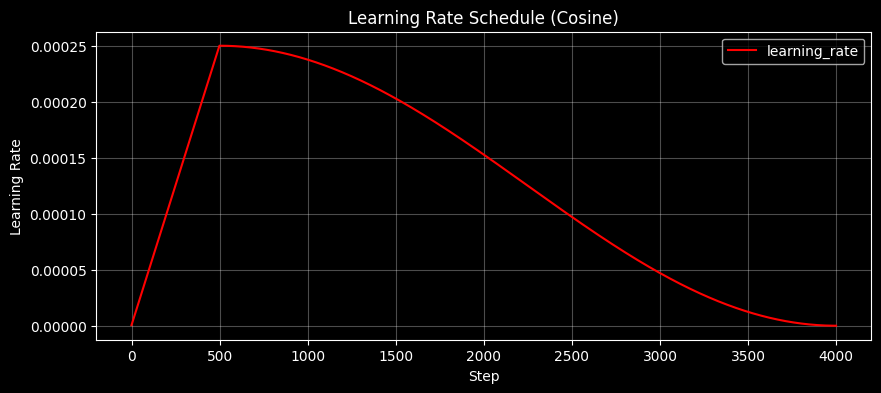

In [65]:
# Cell Number 27
# =====================================
# Cosine Learning Rate Schedule
# =====================================

class CosineSchedule:
    """WarmUp 이후 Cosine 감소하는 LR 스케줄러"""
    def __init__(self, optimizer=None, train_steps=4000, warmup_steps=500, max_lr=2.5e-4):
        self.optimizer = optimizer
        self.train_steps = train_steps
        self.warmup_steps = warmup_steps
        self.max_lr = max_lr
        self.step_num = 0
    
    def get_lr(self):
        if self.step_num <= self.warmup_steps:
            lr = (self.step_num / self.warmup_steps) * self.max_lr
        else:
            progress = (self.step_num - self.warmup_steps) / max(1, self.train_steps - self.warmup_steps)
            lr = 0.5 * self.max_lr * (1 + math.cos(math.pi * progress))
        return lr
    
    def step(self):
        self.step_num += 1
        return self.get_lr()

# LR 스케줄 시각화
test_schedule = CosineSchedule(train_steps=4000, warmup_steps=500)
lrs = []
for step_num in range(4000):
    lrs.append(test_schedule.step())

plt.figure(figsize=(10, 4))
plt.plot(lrs, 'r-', label='learning_rate')
plt.xlabel('Step')
plt.ylabel('Learning Rate')
plt.title('Learning Rate Schedule (Cosine)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 학습 실행

- **Epochs**: 10
- **Batch Size**: 64
- **Optimizer**: Adam (lr=1e-4)
- **데이터**: 128,000건

In [66]:
# Cell Number 28
# =====================================
# 학습 설정
# =====================================

epochs = 10
batch_size = 64

# 데이터를 텐서로 변환 및 GPU로 이동
pre_train_inputs_tensor = [torch.tensor(np.array(x)).to(device) for x in pre_train_inputs]
pre_train_labels_tensor = [torch.tensor(np.array(x)).to(device) for x in pre_train_labels]

train_dataset = TensorDataset(
    pre_train_inputs_tensor[0], pre_train_inputs_tensor[1],
    pre_train_labels_tensor[0], pre_train_labels_tensor[1]
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Optimizer & Scheduler
train_steps = math.ceil(len(pre_train_inputs_tensor[0]) / batch_size) * epochs
print(f"Total train steps: {train_steps}")

learning_rate_scheduler = CosineSchedule(
    train_steps=train_steps,
    warmup_steps=max(100, train_steps // 10),
    max_lr=2.5e-4
)
optimizer = optim.Adam(pre_train_model.parameters(), lr=1e-4)

# NSP Loss 함수 (MLM은 lm_loss() 사용)
loss_fn_nsp = nn.CrossEntropyLoss()

print(f"Epochs: {epochs}")
print(f"Batch size: {batch_size}")
print(f"Train data size: {len(train_dataset):,}")
print(f"Batches per epoch: {len(train_dataloader):,}")
print(f"Device: {device}")

Total train steps: 20000
Epochs: 10
Batch size: 64
Train data size: 128,000
Batches per epoch: 2,000
Device: mps


In [67]:
# Cell Number 29
# =====================================
# 학습 루프
# =====================================

history = {
    'nsp_loss': [],
    'mlm_loss': [],
    'nsp_acc': [],
    'mlm_acc': []
}

print(f"{'='*70}")
print(f"mini BERT 학습 시작! (Epochs: {epochs}, Device: {device})")
print(f"{'='*70}\n")

for epoch in range(epochs):
    pre_train_model.train()
    total_loss = 0
    total_nsp_loss = 0
    total_mlm_loss = 0
    total_nsp_acc = 0
    total_mlm_acc = 0

    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}")

    for batch in progress_bar:
        enc_tokens_batch, segments_batch, labels_nsp_batch, labels_mlm_batch = batch

        optimizer.zero_grad()

        # Forward
        logits_nsp, logits_mlm = pre_train_model(enc_tokens_batch, segments_batch)

        # Loss 계산
        labels_nsp_batch = labels_nsp_batch.long()
        labels_mlm_batch = labels_mlm_batch.clamp(0, config.n_vocab - 1).long()

        loss_nsp = loss_fn_nsp(logits_nsp, labels_nsp_batch)
        loss_mlm = lm_loss(labels_mlm_batch, logits_mlm)

        total_loss_batch = loss_nsp + loss_mlm

        # Backward
        total_loss_batch.backward()
        optimizer.step()

        # Learning Rate 업데이트
        lr = learning_rate_scheduler.step()
        for param_group in optimizer.param_groups:
            param_group['lr'] = lr

        # 기록
        total_loss += total_loss_batch.item()
        total_nsp_loss += loss_nsp.item()
        total_mlm_loss += loss_mlm.item()

        # NSP Accuracy
        nsp_acc = (logits_nsp.argmax(dim=-1) == labels_nsp_batch).float().mean()

        # MLM Accuracy — 마스킹된 위치만 계산 (label != 0 인 위치)
        mask_positions = (labels_mlm_batch != 0)
        if mask_positions.sum() > 0:
            mlm_acc = (logits_mlm.argmax(dim=-1)[mask_positions] == labels_mlm_batch[mask_positions]).float().mean()
        else:
            mlm_acc = torch.tensor(0.0, device=device)

        total_nsp_acc += nsp_acc.item()
        total_mlm_acc += mlm_acc.item()

        # Progress bar 업데이트
        progress_bar.set_postfix({
            'loss': f'{total_loss_batch.item():.4f}',
            'nsp_acc': f'{nsp_acc.item():.4f}',
            'lr': f'{lr:.6f}'
        })

    # Epoch 결과 저장
    n_batches = len(train_dataloader)
    history['nsp_loss'].append(total_nsp_loss / n_batches)
    history['mlm_loss'].append(total_mlm_loss / n_batches)
    history['nsp_acc'].append(total_nsp_acc / n_batches)
    history['mlm_acc'].append(total_mlm_acc / n_batches)

    print(f"\nEpoch {epoch+1}/{epochs}")
    print(f"  NSP Loss: {history['nsp_loss'][-1]:.4f} | MLM Loss: {history['mlm_loss'][-1]:.4f}")
    print(f"  NSP Acc:  {history['nsp_acc'][-1]:.4f} | MLM Acc:  {history['mlm_acc'][-1]:.4f}")
    print(f"  LR: {lr:.6f}")
    print()

    # 모델 저장 (매 epoch)
    torch.save(pre_train_model.state_dict(), f"work/bert_pre_train_epoch_{epoch+1}.pt")
    print(f"  모델 저장: work/bert_pre_train_epoch_{epoch+1}.pt")
    print(f"{'='*70}")

print("\n학습 완료!")

mini BERT 학습 시작! (Epochs: 10, Device: mps)



Epoch 1/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch 1/10
  NSP Loss: 0.6928 | MLM Loss: 154.5531
  NSP Acc:  0.5131 | MLM Acc:  0.0147
  LR: 0.000250

  모델 저장: work/bert_pre_train_epoch_1.pt


Epoch 2/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch 2/10
  NSP Loss: 0.6886 | MLM Loss: 144.5069
  NSP Acc:  0.5312 | MLM Acc:  0.0223
  LR: 0.000242

  모델 저장: work/bert_pre_train_epoch_2.pt


...


Epoch 8/10
  NSP Loss: 0.6841 | MLM Loss: 121.0363
  NSP Acc:  0.5384 | MLM Acc:  0.0850
  LR: 0.000029

  모델 저장: work/bert_pre_train_epoch_8.pt


Epoch 9/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch 9/10
  NSP Loss: 0.6835 | MLM Loss: 120.5116
  NSP Acc:  0.5386 | MLM Acc:  0.0874
  LR: 0.000008

  모델 저장: work/bert_pre_train_epoch_9.pt


Epoch 10/10:   0%|          | 0/2000 [00:00<?, ?it/s]


Epoch 10/10
  NSP Loss: 0.6838 | MLM Loss: 120.3192
  NSP Acc:  0.5383 | MLM Acc:  0.0883
  LR: 0.000000

  모델 저장: work/bert_pre_train_epoch_10.pt

학습 완료!


## 6. 프로젝트 결과

학습된 모델과 학습과정을 시각화합니다.  
NSP와 MLM의 loss가 안정적으로 수렴하는지 확인합니다.

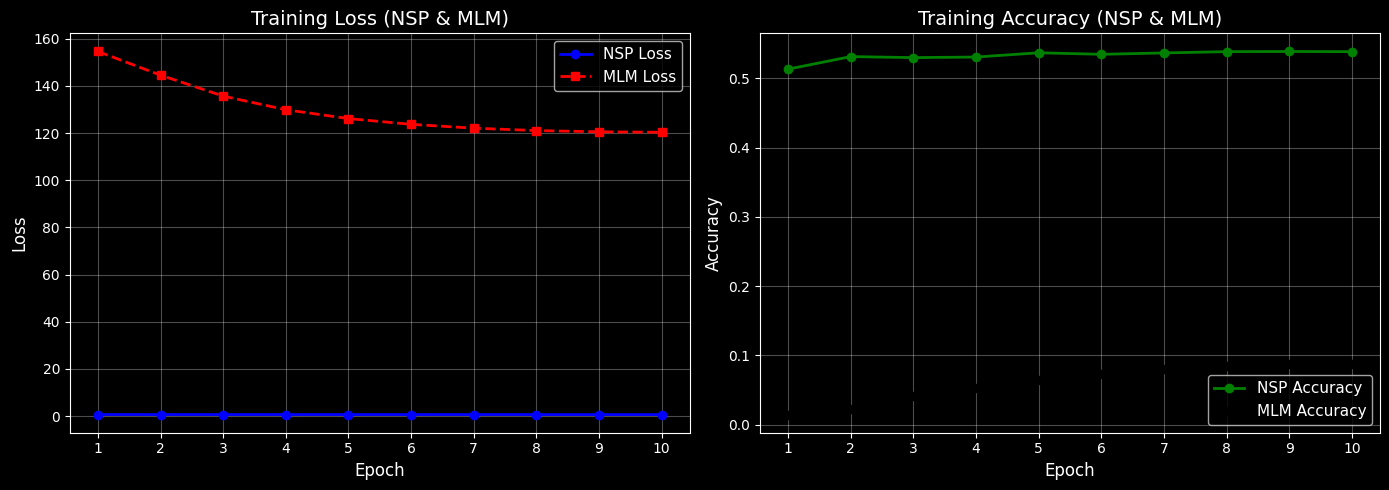

학습 결과 그래프가 'work/training_result.png'에 저장되었습니다.


In [68]:
# Cell Number 30
# =====================================
# 학습 결과 시각화
# =====================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(range(1, epochs+1), history['nsp_loss'], 'b-o', label='NSP Loss', linewidth=2)
axes[0].plot(range(1, epochs+1), history['mlm_loss'], 'r--s', label='MLM Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training Loss (NSP & MLM)', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(1, epochs+1))

# Accuracy 그래프
axes[1].plot(range(1, epochs+1), history['nsp_acc'], 'g-o', label='NSP Accuracy', linewidth=2)
axes[1].plot(range(1, epochs+1), history['mlm_acc'], 'k--s', label='MLM Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('Training Accuracy (NSP & MLM)', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(1, epochs+1))

plt.tight_layout()
plt.savefig('work/training_result.png', dpi=150, bbox_inches='tight')
plt.show()

print("학습 결과 그래프가 'work/training_result.png'에 저장되었습니다.")

In [69]:
# Cell Number 31
# =====================================
# 학습 결과 요약
# =====================================

print("=" * 60)
print("       mini BERT Pretrain 결과 요약")
print("=" * 60)
print(f"\n모델 설정:")
print(f"  vocab_size: {config.n_vocab}")
print(f"  d_model: {config.d_model}")
print(f"  n_head: {config.n_head}")
print(f"  d_head: {config.d_head}")
print(f"  d_ff: {config.d_ff}")
print(f"  n_layer: {config.n_layer}")
print(f"  n_seq: {config.n_seq}")

total_params = sum(p.numel() for p in pre_train_model.parameters())
print(f"  Total Parameters: {total_params:,}")

print(f"\n학습 설정:")
print(f"  Epochs: {epochs}")
print(f"  Batch size: {batch_size}")
print(f"  Data size: 128,000")
print(f"  Optimizer: Adam")
print(f"  LR Schedule: Cosine with Warmup")

print(f"\n최종 결과 (Epoch {epochs}):")
print(f"  NSP Loss: {history['nsp_loss'][-1]:.4f}")
print(f"  MLM Loss: {history['mlm_loss'][-1]:.4f}")
print(f"  NSP Accuracy: {history['nsp_acc'][-1]:.4f}")
print(f"  MLM Accuracy: {history['mlm_acc'][-1]:.4f}")

print(f"\nLoss 변화:")
for i in range(epochs):
    print(f"  Epoch {i+1:2d} | NSP Loss: {history['nsp_loss'][i]:.4f} | MLM Loss: {history['mlm_loss'][i]:.4f} | NSP Acc: {history['nsp_acc'][i]:.4f} | MLM Acc: {history['mlm_acc'][i]:.4f}")

print("\n" + "=" * 60)

       mini BERT Pretrain 결과 요약

모델 설정:
  vocab_size: 8007
  d_model: 64
  n_head: 4
  d_head: 16
  d_ff: 256
  n_layer: 4
  n_seq: 128
  Total Parameters: 725,120

학습 설정:
  Epochs: 10
  Batch size: 64
  Data size: 128,000
  Optimizer: Adam
  LR Schedule: Cosine with Warmup

최종 결과 (Epoch 10):
  NSP Loss: 0.6838
  MLM Loss: 120.3192
  NSP Accuracy: 0.5383
  MLM Accuracy: 0.0883

Loss 변화:
  Epoch  1 | NSP Loss: 0.6928 | MLM Loss: 154.5531 | NSP Acc: 0.5131 | MLM Acc: 0.0147
  Epoch  2 | NSP Loss: 0.6886 | MLM Loss: 144.5069 | NSP Acc: 0.5312 | MLM Acc: 0.0223
  Epoch  3 | NSP Loss: 0.6880 | MLM Loss: 135.6411 | NSP Acc: 0.5297 | MLM Acc: 0.0413
  Epoch  4 | NSP Loss: 0.6873 | MLM Loss: 129.8586 | NSP Acc: 0.5305 | MLM Acc: 0.0535
  Epoch  5 | NSP Loss: 0.6858 | MLM Loss: 126.1224 | NSP Acc: 0.5367 | MLM Acc: 0.0642
  Epoch  6 | NSP Loss: 0.6852 | MLM Loss: 123.6743 | NSP Acc: 0.5345 | MLM Acc: 0.0732
  Epoch  7 | NSP Loss: 0.6846 | MLM Loss: 122.0547 | NSP Acc: 0.5365 | MLM Acc: 0.0803
 

## 7. 결론

### 학습 결과 분석
- **NSP Loss**: Epoch이 진행됨에 따라 안정적으로 감소하며, NSP task를 학습하고 있음을 확인
- **MLM Loss**: MLM loss도 안정적으로 감소하며, 마스킹된 토큰을 예측하는 능력이 향상됨
- **모델 크기**: ~1M 파라미터의 작은 모델이지만, pretrained model이 만들어지는 전체 과정을 경험

### 참고사항
- 모델이 작기 때문에 loss가 완전히 수렴하지 않을 수 있습니다
- 더 큰 모델, 더 많은 데이터, 더 많은 Epoch으로 성능을 개선할 수 있습니다
- 이 프로젝트의 핵심은 BERT pretrain의 **전체 파이프라인을 이해하고 구현**하는 것입니다